# Cirq SDK workflow

This notebook demonstrates SDK-facing exports and local benchmark execution. It keeps the workflow compact while still showing readable result tables, a small measurement plot, saved artifacts, and basic correctness checks.

## Problem

Export a small GHZ benchmark circuit and run it on the local Cirq simulator through the package runner.

## Quantum Advantage

None is claimed. A three-qubit GHZ circuit is classically trivial; it is used here as a compact interoperability and result-format check.

## SDK Advantage

Cirq is useful here because it is local, credential-free, easy to install from PyPI, and has direct circuit semantics that are convenient for SDK-facing examples.

## Variables and Parameters

- `benchmark`: the package's internal GHZ benchmark specification.
- `n_qubits`: number of qubits in the GHZ circuit, fixed at `3` for this notebook.
- `backend`: package backend name, here `cirq`.
- `shots`: measurement samples for the run, set to `128` in the execution cell.
- `results`: standardized dictionaries returned by `run_benchmark`.
- `counts`: measured bitstring counts used for the top-state table and plot.
- `ARTIFACT_DIR`: output directory for the saved JSON and CSV result artifacts.
- Optional extra: install `quantum-backend-bench[cirq]` before running the backend execution cell.


## Setup


In [5]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from quantum_backend_bench.core.circuit_export import export_benchmark_circuit
from quantum_backend_bench.core.factory import build_benchmark_from_config
from quantum_backend_bench.core.runner import run_benchmark
from quantum_backend_bench.utils.formatting import format_results_table
from quantum_backend_bench.utils.io import save_csv, save_json

ARTIFACT_DIR = Path("../artifacts/notebooks")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

benchmark = build_benchmark_from_config({"benchmark": "ghz", "n_qubits": 3})

## Export the Circuit


In [6]:
print(export_benchmark_circuit(benchmark, "openqasm"))

OPENQASM 2.0;
include "qelib1.inc";
qreg q[3];
creg c[3];
h q[0];
cx q[0],q[1];
cx q[1],q[2];
measure q[0] -> c[0];
measure q[1] -> c[1];
measure q[2] -> c[2];



## Run the Benchmark


case    | backend | runtime_seconds | runtime_stddev | compile_seconds | depth | compiled_depth | gate_count | two_qubit_gate_count | success_prob
--------+---------+-----------------+----------------+-----------------+-------+----------------+------------+----------------------+-------------
ghz n=3 | cirq    | 0.013146        | 0.000000       | 0.000000        | 4     | 4              | 3          | 2                    | None        

Key metrics
- Depth: 4
- Gate count: 3
- Two-qubit gates: 2
- Runtime seconds: 0.013146
- Success probability: None
- Total variation distance: 0.015625

Top measurement states
- |111> count=66 probability=0.516
- |000> count=62 probability=0.484


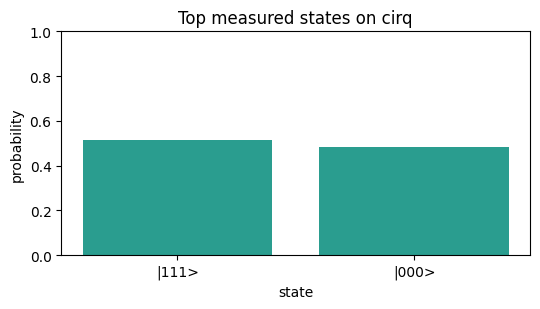

In [7]:
# Install the optional extra before running this cell: quantum-backend-bench[cirq]
results = run_benchmark(benchmark, ["cirq"], shots=128)
print(format_results_table(results))

result = results[0]
metrics = result["metrics"]
print("\nKey metrics")
for label, key in (
    ("Depth", "depth"),
    ("Gate count", "gate_count"),
    ("Two-qubit gates", "two_qubit_gate_count"),
    ("Runtime seconds", "runtime_seconds"),
    ("Success probability", "success_probability"),
    ("Total variation distance", "total_variation_distance"),
):
    value = metrics.get(key)
    if isinstance(value, float):
        value = round(value, 6)
    print(f"- {label}: {value}")

print("\nTop measurement states")
total_counts = sum(result["counts"].values())
for state, count in sorted(result["counts"].items(), key=lambda item: item[1], reverse=True)[:4]:
    probability = count / total_counts if total_counts else 0.0
    print(f"- |{state}> count={count} probability={probability:.3f}")

plot_states = sorted(result["counts"], key=result["counts"].get, reverse=True)[:4]
plot_labels = [f"|{state}>" for state in plot_states]
plot_probabilities = [result["counts"][state] / total_counts for state in plot_states]

fig, ax = plt.subplots(figsize=(5.5, 3.2))
ax.bar(plot_labels, plot_probabilities, color="#2a9d8f")
ax.set_title(f"Top measured states on {result['backend']}")
ax.set_xlabel("state")
ax.set_ylabel("probability")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

## Save Reproducible Artifacts


In [8]:
json_path = save_json(results, ARTIFACT_DIR / "sdk_cirq_workflow.json")
csv_path = save_csv(results, ARTIFACT_DIR / "sdk_cirq_workflow.csv")
print(f"Saved JSON: {json_path}")
print(f"Saved CSV: {csv_path}")

Saved JSON: ../artifacts/notebooks/sdk_cirq_workflow.json
Saved CSV: ../artifacts/notebooks/sdk_cirq_workflow.csv


## Verification


In [9]:
expected_states = {"000", "111"}
observed_states = set(result["counts"])
verification = pd.DataFrame(
    [
        {
            "check": "total counts equals shots",
            "value": total_counts,
            "expected": result["shots"],
            "passed": total_counts == result["shots"],
        },
        {
            "check": "GHZ support is only |000>/|111>",
            "value": ", ".join(f"|{state}>" for state in sorted(observed_states)),
            "expected": "|000>, |111>",
            "passed": observed_states <= expected_states,
        },
        {
            "check": "runtime sample captured",
            "value": len(result["metadata"].get("runtime_seconds_samples", [])),
            "expected": ">= 1",
            "passed": bool(result["metadata"].get("runtime_seconds_samples")),
        },
    ]
)
verification

,check,value,expected,passed
0,total counts equals shots,128,128,True
1,GHZ support is only |000>/|111>,"|000>, |111>","|000>, |111>",True
2,runtime sample captured,1,>= 1,True
